Домашнее задание №18. Кручинин С.В.
Урок 47.

Запускать из папки дз18. Файл priznaki.csv лежит рядом.

Вопрос:
На основе датасета, который был использован для промежуточной аттестации.

In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

df = pd.read_csv('priznaki.csv')
print('всего строк', len(df))
print(df['prosrochka'].value_counts().sort_index())


всего строк 96
prosrochka
0    80
1    16
Name: count, dtype: int64


Ответ:
Взял priznaki.csv. Просрочка есть у всех строк, ничего не выкидывал. 96 строк.

Вопрос:
Выберите бинарную переменную (или сконструируйте из количественной).

Ответ:
Таргет prosrochka, уже 0 или 1. Просрочек 16 из 96.

Вопрос:
Выберите несколько объясняющих переменных.

Ответ:
vozrast, tema_sovpala, zhanr_sovpal, skok_brali.
Срок в днях везде 14, его не брал.

Вопрос:
Разделите датасет на обучающую и тестовую выборки.

In [2]:
cols = ['vozrast', 'tema_sovpala', 'zhanr_sovpal', 'skok_brali']
Xtr, Xte, ytr, yte = train_test_split(df[cols], df['prosrochka'].astype(int), test_size=0.33, random_state=42, stratify=df['prosrochka'])
print('обучение', len(ytr), 'просрочек', int(ytr.sum()))
print('тест', len(yte), 'просрочек', int(yte.sum()))


обучение 64 просрочек 11
тест 32 просрочек 5


Ответ:
test_size = 0.33, random_state = 42, stratify по prosrochka. Обучение 64, из них просрочек 11. Тест 32, из них просрочек 5.

Вопрос:
Обучите модель KNN на обучающей выборке.

In [3]:
scaler = StandardScaler()
Ztr = scaler.fit_transform(Xtr)
Zte = scaler.transform(Xte)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Ztr, ytr)
proba = knn.predict_proba(Zte)[:, 1]
print('k', 5)
print('AUC', round(roc_auc_score(yte, proba), 3))
print('среднее', [round(float(v), 3) for v in scaler.mean_])
print('масштаб', [round(float(v), 3) for v in scaler.scale_])


k 5
AUC 0.826
среднее [29.219, 0.188, 0.25, 5.453]
масштаб [7.835, 0.39, 0.433, 3.455]


Ответ:
k = 5, как в тетради. Признаки масштабировал, fit только на обучении. AUC на тесте 0.826.

Вопрос:
Постройте графики recall-precision и roc.

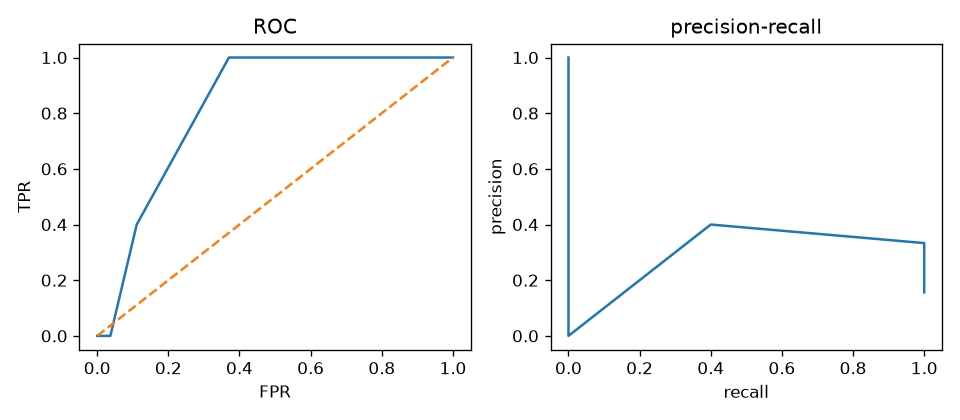

In [4]:
fpr, tpr, _ = roc_curve(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC')
axes[1].plot(rec, prec)
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_title('precision-recall')
plt.tight_layout()
plt.savefig('dz18_grafiki.png', dpi=120)
plt.show()


Ответ:
ROC выше диагонали, AUC 0.826.
precision-recall: при пороге 0.5 precision 0.4 и recall 0.4. При пороге 0.4 recall 1.0, precision 0.333.

Вопрос:
Выберите и обоснуйте порог предсказания Y = 1.

In [5]:
for t in (0.5, 0.4):
    pred = (proba >= t).astype(int)
    print('порог', t)
    print('accuracy', round(accuracy_score(yte, pred), 3),
          'precision', round(precision_score(yte, pred, zero_division=0), 3),
          'recall', round(recall_score(yte, pred, zero_division=0), 3),
          'F1', round(f1_score(yte, pred, zero_division=0), 3))
    print('матрица', confusion_matrix(yte, pred).tolist())


порог 0.5
accuracy 0.812 precision 0.4 recall 0.4 F1 0.4
матрица [[24, 3], [3, 2]]
порог 0.4
accuracy 0.688 precision 0.333 recall 1.0 F1 0.5
матрица [[17, 10], [0, 5]]


Ответ:
При k = 5 вероятность равна 0, 0.2, 0.4, 0.6 или 0.8. Это доля просрочивших среди пяти соседей.
Порог 0.5 срабатывает от трёх соседей. На тесте так поймано 2 из 5, пропущено 3.
Порог 0.4 срабатывает от двух соседей. На тесте пойманы все 5, ложных тревог 10.
Должника пропустить хуже, чем лишний раз проверить. Беру порог 0.4.

Вопрос:
Сделайте предсказания целевой переменной для тестовой выборки.

In [6]:
pred = (proba >= 0.4).astype(int)
tab = pd.DataFrame({'факт': yte.to_numpy(), 'вероятность': np.round(proba, 1), 'прогноз': pred})
print(tab.to_string(index=False))


 факт  вероятность  прогноз
    0          0.0        0
    0          0.0        0
    1          0.4        1
    0          0.0        0
    0          0.4        1
    0          0.0        0
    0          0.0        0
    0          0.0        0
    0          0.2        0
    0          0.0        0
    0          0.2        0
    0          0.0        0
    0          0.0        0
    0          0.0        0
    0          0.4        1
    1          0.6        1
    0          0.4        1
    0          0.6        1
    0          0.4        1
    0          0.6        1
    0          0.0        0
    0          0.4        1
    0          0.0        0
    0          0.4        1
    0          0.4        1
    0          0.2        0
    0          0.8        1
    1          0.6        1
    0          0.2        0
    1          0.4        1
    1          0.4        1
    0          0.0        0


Ответ:
Прогноз на 32 строках теста при пороге 0.4. Таблица выше.

Вопрос:
Постройте матрицу ошибок.

In [7]:
print(confusion_matrix(yte, pred).tolist())


[[17, 10], [0, 5]]


Ответ:
Строки факт, столбцы прогноз. [[17, 10], [0, 5]]. Вовремя и угадано 17, ложная тревога 10, пропущенная просрочка 0, пойманная просрочка 5.

Вопрос:
Рассчитайте метрики качества.

In [8]:
print('accuracy', round(accuracy_score(yte, pred), 3),
      'precision', round(precision_score(yte, pred, zero_division=0), 3),
      'recall', round(recall_score(yte, pred, zero_division=0), 3),
      'F1', round(f1_score(yte, pred, zero_division=0), 3),
      'AUC', round(roc_auc_score(yte, proba), 3))


accuracy 0.688 precision 0.333 recall 1.0 F1 0.5 AUC 0.826


Ответ:
accuracy 0.688, precision 0.333, recall 1.0, F1 0.5, AUC 0.826.

Вопрос:
Сделайте выводы относительно полученной модели, ее качества и полученных зависимостей.

In [9]:
print(df.groupby('prosrochka')[cols].mean().round(3))


            vozrast  tema_sovpala  zhanr_sovpal  skok_brali
prosrochka                                                 
0            30.038          0.20          0.25       5.688
1            20.312          0.25          0.25       5.688


Ответ:
AUC 0.826, это выше случайного 0.5, но до единицы далеко. При пороге 0.4 recall 1.0, precision 0.333: из 15 тревог верных 5. Для библиотеки так лучше, чем пропускать должников, но список на проверку длинный. У просрочивших средний возраст 20.312, у остальных 30.038. Тема совпала: 0.25 и 0.2. Жанр совпал: 0.25 и 0.25. Сколько раз брали: 5.688 и 5.688. Отличается в основном возраст, молодые сдают позже.

Вопрос:
Разместите блокнот в GitHub и прикрепите ссылку.

Ответ:
Ссылка на блокнот: https://github.com/ubersk-debug/pg-kruchinin/blob/master/дз18/dz18_knn.ipynb